# Deep Learning - Exercise 8

The aim of this exercise is to learn how to implement and utilize attention mechanisms in deep learning models, focusing on how these techniques allow models to selectively focus on the most relevant parts of input data.

**Core Concepts**
* 🧠 Attention mechanism fundamentals and mathematical foundations
* 🔍 Types of attention mechanisms (Self-attention, Dot-product)
* 📊 Applications in natural language processing
* ⚙️ Implementation of attention-based models

We recommend reading [this post](https://analyticsindiamag.com/a-beginners-guide-to-using-attention-layer-in-neural-networks/) for more detailed information.

[Open in Google colab](https://colab.research.google.com/github/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/dl_08.ipynb)
[Download from Github](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/dl_08.ipynb)

##### Remember to set **GPU** runtime in Colab!

In [42]:
# !pip install keract
!pip install attention

In [43]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np 
import pandas as pd
import seaborn as sns
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow import string as tf_string
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.layers import LSTM, GRU, Bidirectional, Dense, Layer

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import os

# from keract import get_activations
from keras import Input, Model
from tensorflow.keras.callbacks import Callback
import keras.backend as K

os.environ['KERAS_ATTENTION_DEBUG'] = '1'
from attention import Attention

plt.rcParams.update({'font.size': 8})

keras.utils.set_random_seed(13)
tf.version.VERSION

'2.21.0'

In [44]:
def show_history(history):
    plt.figure()
    for key in history.history.keys():
        plt.plot(history.epoch, history.history[key], label=key)
    plt.legend()
    plt.tight_layout()

# 📒 What is the Attention mechanism?

* When we think about the English word **Attention**, we know that it means **directing your focus at something** and taking greater notice
* The Attention mechanism in Deep Learning is based off this concept of directing your focus, and it pays greater attention to certain factors when processing the data
    * 📌 Paying attention to important information is necessary and it can improve the performance of the model
* **Attention mechanism can help a neural network to memorize long sequences of the information**
    * 🔎 Remember the RNN and even LSTM long-context issues?
* 🔎 Can you imagine some use-cases where it can help us?

> 💡 In very simple terms the Attention mechanism makes sure that the forget mechanism of LSTM layers is not applied over the important pieces of information

### The process is usually computed in these few steps

![Img00](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/images/dl_08_04.png?raw=true)

* Let’s say that we have an input with n sequences and output y with m sequence in a network
    * $x=[x_1, x_2, ..., x_n]$
    * $y = [y_1, y_2, ..., y_n]$
    
* The encoder which we are using in the network is a bidirectional LSTM network where it has a forward hidden state and a backward hidden state
    * Representation of the encoder state can be done by concatenation of these forward and backward states
    * $h_i = [h_i^{L2R}, h_i^{R2L}]$

* The hidden state is:
    * $s_t=f(s_{t-1}, y_{t-1}, c_t)$
    
* For the output word at position t, the context vector $C_t$ can be the sum of the hidden states of the input sequence
* Thus we have:

![Img02](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/images/dl_08_02.png?raw=true)

* Here we can see that the sum of the hidden state is weighted by the alignment scores
* 💡 We can say that ${\alpha_{t,i}}$  are the weights that are responsible for defining how much of each source’s hidden state should be taken into consideration for each output

* 💡 There can be various types of alignment scores according to their geometry
    * It can be either linear or in the curve geometry

### 📌 Below are some of the popular attention mechanisms:

![Img03](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/images/dl_08_03.png?raw=true)

#### 💡 There are many variants of the mechanism in the wild but the basic computation process is the same

### The very common and easy to understand example is **Self-Attention Mechanism**
* When an attention mechanism is applied to the network so that it can relate to different positions of a single sequence and can compute the representation of the same sequence, it can be considered as self-attention

![Img01](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/images/dl_08_01.png?raw=true)

* Here in the image, the red color represents the word which is currently learning and the blue color is of the memory, and the intensity of the color represents the degree of memory activation

## ⚡ We will use Attention layer from the library first and try to solve the *Find-Max task*
* What is the *Find-Max* task?

In [45]:
def generate_data(num_samples, seq_length):
    X = np.random.uniform(0, 10, (num_samples, seq_length, 1))
    y = np.max(X, axis=1)  # Find maximum value in each sequence
    return X, y

seq_length = 15
# Generate 10,000 sequences of length 15
X_train, y_train = generate_data(10000, seq_length)
X_test, y_test = generate_data(1000, seq_length)

## ⚡ We will employ a simple LSTM-based model with attention layer stacked to it
* 🔎 What is the intuition behind using attention?

In [46]:
inputs = Input(shape=(seq_length, 1))
x = LSTM(64, return_sequences=True)(inputs)
x = Attention(units=32)(x)  # Bahdanau-style additive attention
outputs = Dense(1)(x)
model = Model(inputs, outputs)
model.compile(loss='mse', optimizer='adam')
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 15, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ (None, 15, 64)    │     16,896 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ last_hidden_state   │ (None, 64)        │          0 │ lstm_7[0][0]      │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ luong_w (Dense)     │ (None, 15, 64)    │      4,096 │ lstm_7[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_score     │ (None, 15)        │          0 │ last_hidden_stat… │
│ (Dot)               │                   │            │ luong_w[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weight    │ (None, 15)        │          0 │ attention_score[… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_vector      │ (None, 64)        │          0 │ lstm_7[0][0],     │
│ (Dot)               │                   │            │ attention_weight… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_output    │ (None, 128)       │          0 │ context_vector[0… │
│ (Concatenate)       │                   │            │ last_hidden_stat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_vector    │ (None, 32)        │      4,096 │ attention_output… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         33 │ attention_vector… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,121 (98.13 KB)

 Trainable params: 25,121 (98.13 KB)

 Non-trainable params: 0 (0.00 B)

## We want to access the attention weights so we need to create a custom model to access it

In [47]:
model.layers

[<InputLayer name=input_layer_7, built=True>,
 <LSTM name=lstm_7, built=True>,
 <Lambda name=last_hidden_state, built=True>,
 <Dense name=luong_w, built=True>,
 <Dot name=attention_score, built=True>,
 <Activation name=attention_weight, built=True>,
 <Dot name=context_vector, built=True>,
 <Concatenate name=attention_output, built=True>,
 <Dense name=attention_vector, built=True>,
 <Dense name=dense_4, built=True>]

In [48]:
visualization_model = Model(
    inputs=inputs,
    outputs=[model.layers[-1].output, model.layers[4].output]  # Access attention layer
)

# 🚀 Let's train the model

In [49]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=32
)

Epoch 1/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 3.0516 - val_loss: 0.3338
Epoch 2/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3553 - val_loss: 0.3193
Epoch 3/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3176 - val_loss: 0.2848
Epoch 4/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2719 - val_loss: 0.2811
Epoch 5/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2020 - val_loss: 0.1832
Epoch 6/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1175 - val_loss: 0.0797
Epoch 7/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0529 - val_loss: 0.0357
Epoch 8/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0272 - val_loss: 0.0179
Epoch 9/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0194 - val_loss: 0.0142
Epoch 10/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0151 - val_loss: 0.0118
Epoch 11/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0119 - val_loss: 0.0099
Epoch 12/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

## Now we can predict the values for the testing set

In [50]:
preds = model.predict(X_test)
preds.ravel()[:10], y_test.ravel()[:10]

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


(array([9.927574, 9.146364, 9.654832, 9.028508, 9.832984, 9.352681,
        7.990854, 9.410791, 9.855612, 9.316513], dtype=float32),
 array([9.87880117, 9.10068569, 9.63193881, 8.89109298, 9.7829609 ,
        9.32795348, 7.99399699, 9.34653919, 9.75892522, 9.29271441]))

## 💡 How should the predicted vs. true values scatter plot look like?

<Axes: >

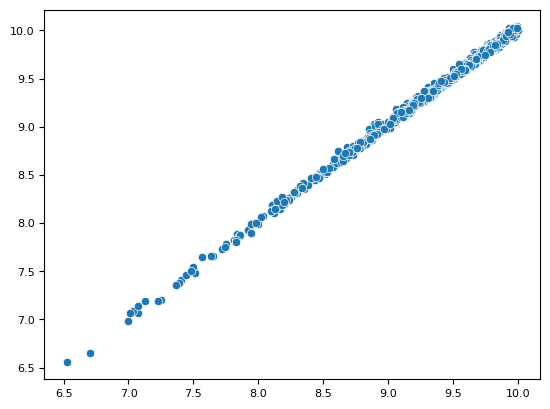

In [51]:
sns.scatterplot(x=y_test.ravel(), y=preds.ravel())

In [52]:
# Test with sample sequence
prediction_arr, attention_weights_arr = [], []
for i in range(12):
    prediction, attention_weights = visualization_model.predict(X_test[i])
    prediction_arr.append(prediction)
    attention_weights_arr.append(attention_weights)
# prediction, attention_weights = visualization_model.predict(X_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


/home/ajra/Code/HU/venv/lib64/python3.11/site-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (15, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


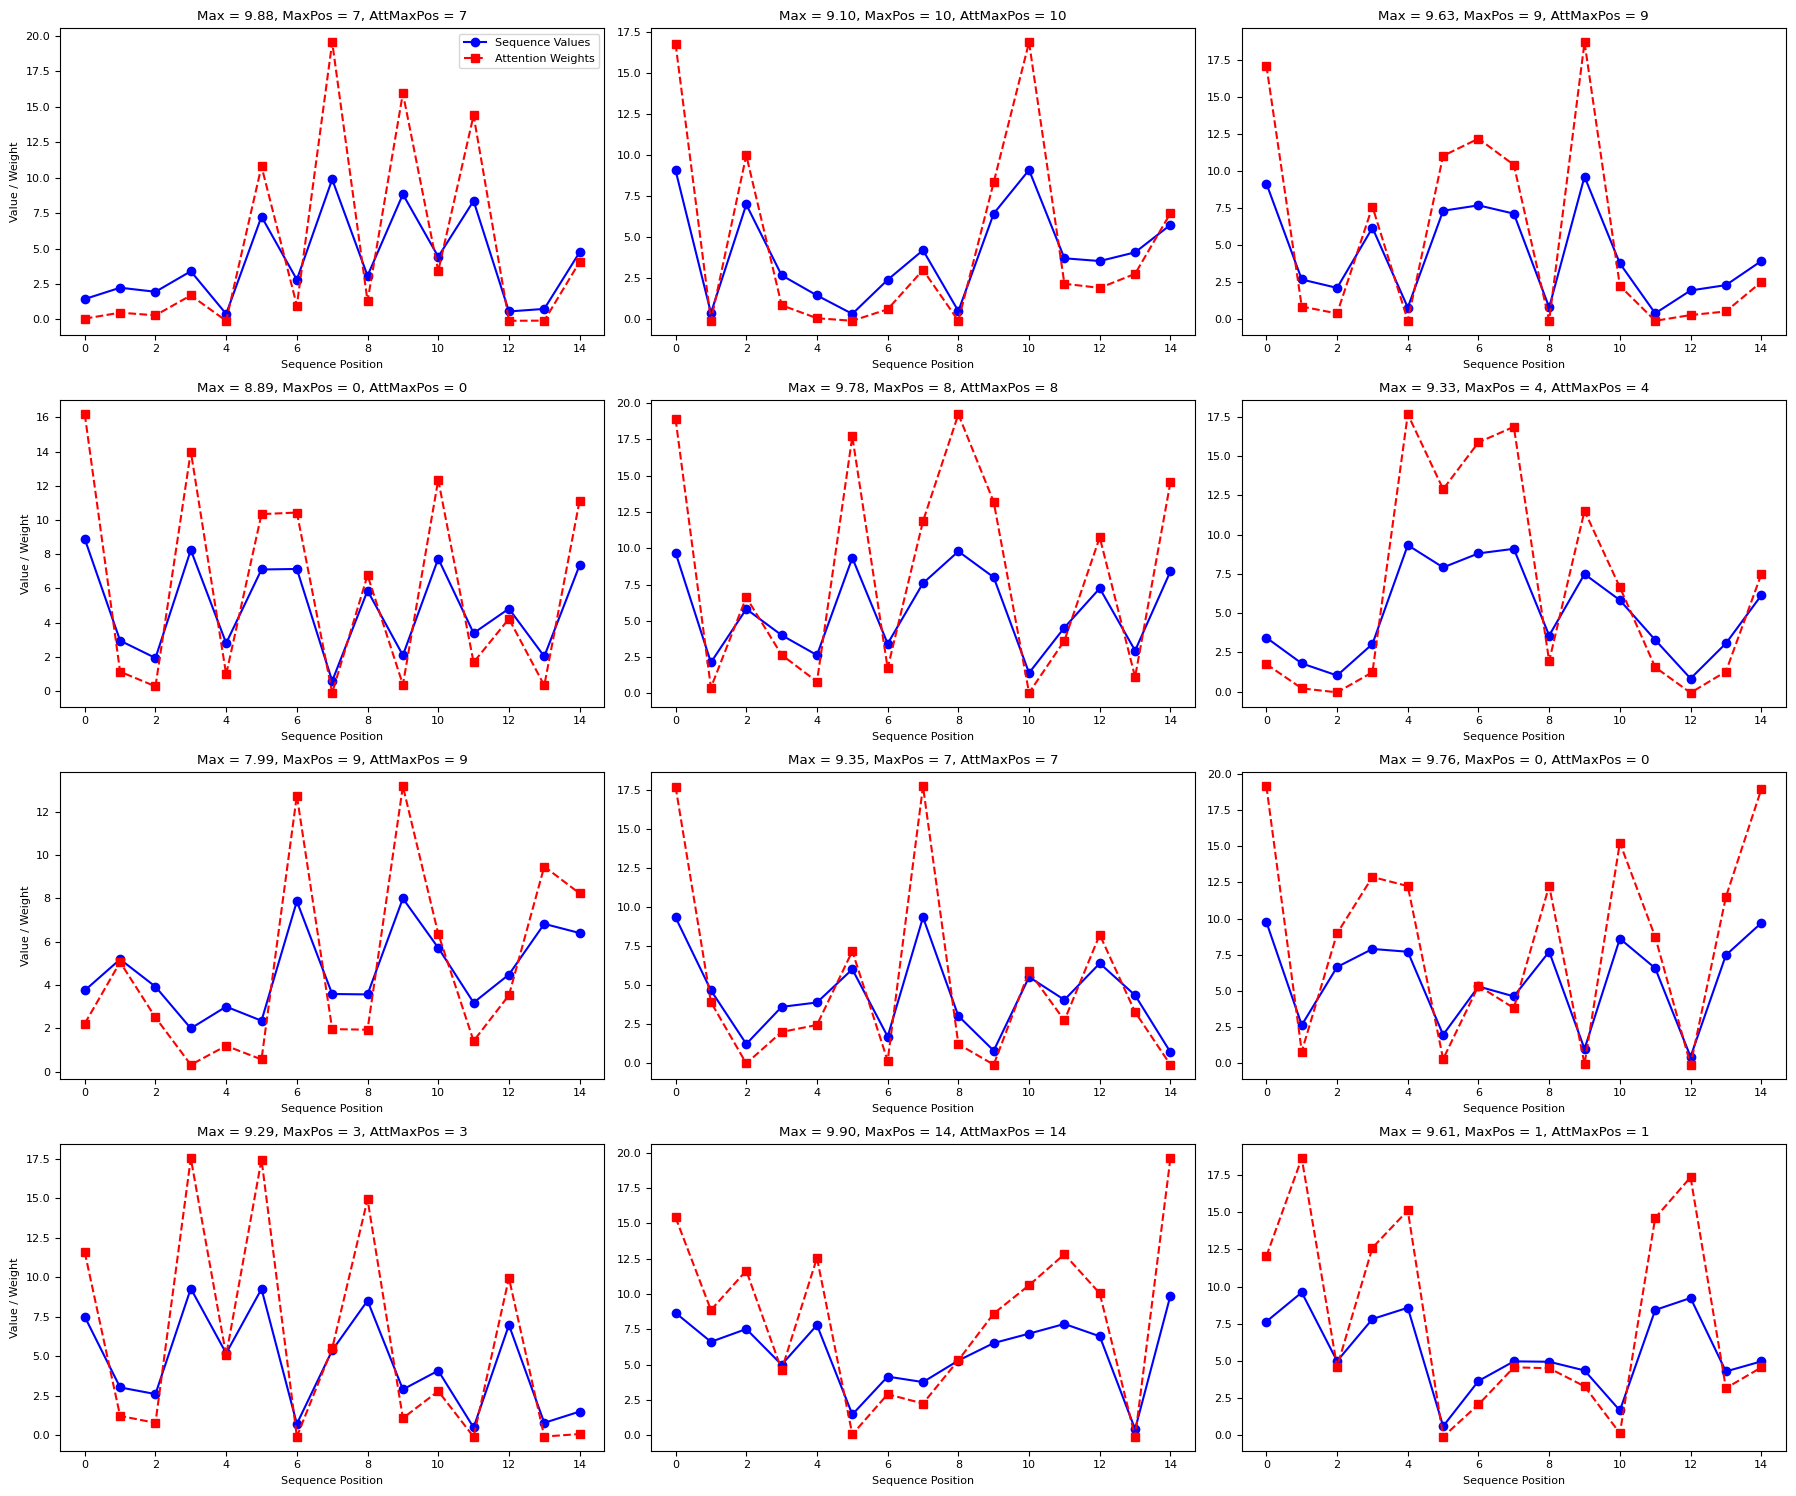

In [53]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 15))
gs = gridspec.GridSpec(4, 3)

for i in range(12):
    ax = plt.subplot(gs[i//3, i%3])
    ax.plot(X_test[i], 'b-o', label='Sequence Values')
    ax.plot(attention_weights_arr[i], 'r--s', label='Attention Weights')
    ax.set_title(f'Max = {y_test[i][0]:.2f}, MaxPos = {np.argmax(X_test[i])}, AttMaxPos = {np.argmax(attention_weights_arr[i])}')
    ax.set_xlabel('Sequence Position')
    if i % 3 == 0:
        ax.set_ylabel('Value / Weight')
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()

## ⚡ Now as we know how the Attention layer works we can employ it for the sentiment analysis task
* We will use Yelp dataset which contains reviews of restaurants with either positive (1) or negative (0) labels assigned

## Download and load the dataset

In [54]:
path_to_file = tf.keras.utils.get_file('yelp_labelled.txt', 'https://raw.githubusercontent.com/rasvob/VSB-FEI-Deep-Learning-Exercises/main/datasets/yelp_labelled.txt')

In [55]:
path_to_file

'/home/ajra/.keras/datasets/yelp_labelled.txt'

In [56]:
with open(path_to_file) as f:
    lines = f.readlines()
    lines = [x.rstrip() for x in lines]

In [57]:
len(lines)

3000

In [58]:
lines_dict = [{'Text': x[:-1].rstrip(), 'Label': int(x[-1])} for x in lines]

In [59]:
df = pd.DataFrame.from_dict(lines_dict)

In [60]:
df.head()

,Text,Label
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


### ⚡ We will use TextVectorization layer as usuall and we will create baseline model without the Attention layer first

In [61]:
embedding_dim = 64 # Dimension of embedded representation - this is already part of latent space, there is captured some dependecy among words, we are learning this vectors in ANN
max_tokens = 3000
sequence_length = 32 # Output dimension after vectorizing - words in vectorited representation are independent

vect_layer = TextVectorization(max_tokens=max_tokens, output_mode='int', output_sequence_length=sequence_length)
vect_layer.adapt(df.Text.values)

In [62]:
vocab = vect_layer.get_vocabulary()

##  The dataset is balanced
* 💡 We will use `stratify` parameter of the `train_test_split` to make sure that it stays balanced

In [63]:
df.Label.value_counts()

Label
1    1500
0    1500
Name: count, dtype: int64

In [64]:
X_train, X_test, y_train, y_test = train_test_split(df.Text, df.Label, test_size=0.20, random_state=13, stratify=df.Label)

In [65]:
X_train = X_train.astype(str).to_numpy()
X_test = X_test.astype(str).to_numpy()

In [66]:
print(X_train.shape, X_test.shape)

(2400,) (600,)


In [67]:
print('Train')
print(y_train.value_counts())
print('Test')
print(y_test.value_counts())

Train
Label
0    1200
1    1200
Name: count, dtype: int64
Test
Label
0    300
1    300
Name: count, dtype: int64


## Let's define very simple model first

This LSTM layer processes sequential data from the preceding embedding layer (`emb`), generates a 50-dimensional output vector, and applies two types of dropout regularization to combat overfitting


### Key Components of LSTM
1. **Units (50)**  
   - The LSTM layer contains 50 memory cells, each capable of learning long-term dependencies in sequential data
   - The final output (`x`) is a 50-dimensional vector summarizing the sequence’s contextual information

2. **Dropout (0.3)**  
   - **Input Dropout**: Randomly drops 30% of input units during training to prevent overfitting
   - Example: If the embedding layer outputs 300-dimensional vectors, 90 features (30% of 300) are masked in each training step 

3. **Recurrent Dropout (0.4)**  
   - Drops 40% of the recurrent connections (hidden state transitions between timesteps) during training
   - This specifically regularizes the LSTM’s internal memory mechanisms

In [68]:
input_layer = keras.layers.Input(shape=(1,), dtype=tf_string)
x_v = vect_layer(input_layer)
emb = keras.layers.Embedding(len(vocab), output_dim=embedding_dim, embeddings_regularizer=keras.regularizers.l2(.001))(x_v)
x = LSTM(50, dropout=0.3, recurrent_dropout=0.4)(emb)
output_layer = keras.layers.Dense(1, 'sigmoid')(x)

model = keras.Model(input_layer, output_layer)
model.summary()

model.compile(optimizer=keras.optimizers.AdamW(), loss=keras.losses.BinaryCrossentropy(from_logits=False), metrics=[keras.metrics.BinaryAccuracy()])

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_1            │ (None, 32)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_6 (Embedding)         │ (None, 32, 64)         │       192,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 50)             │        23,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,051 (840.04 KB)

 Trainable params: 215,051 (840.04 KB)

 Non-trainable params: 0 (0.00 B)

In [69]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - binary_accuracy: 0.4839 - loss: 0.8007 - val_binary_accuracy: 0.5042 - val_loss: 0.7517
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - binary_accuracy: 0.5010 - loss: 0.7283 - val_binary_accuracy: 0.5375 - val_loss: 0.7094
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - binary_accuracy: 0.5177 - loss: 0.7018 - val_binary_accuracy: 0.5083 - val_loss: 0.6964
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - binary_accuracy: 0.4990 - loss: 0.6950 - val_binary_accuracy: 0.4938 - val_loss: 0.6939
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - binary_accuracy: 0.5089 - loss: 0.6934 - val_binary_accuracy: 0.4958 - val_loss: 0.6937
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - binary_accuracy: 0.5078 - loss: 0.6935 - val_binary_accuracy: 0.5667 - val_loss: 0.6931
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - binary_accuracy: 0.5745 - loss: 0.6816 - val_binary_accuracy: 0.5437 - val_loss: 0.6823
Epoch 8/20
1

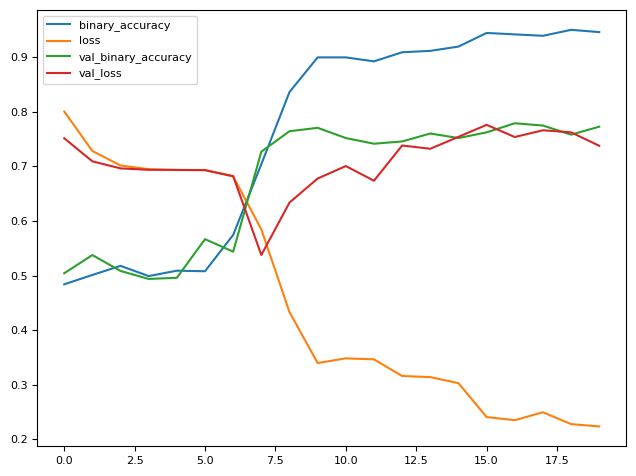

In [70]:
batch_size = 128
epochs = 20

history = model.fit(X_train, y_train.values, validation_split=0.2, callbacks=[model_checkpoint_callback], epochs=epochs, batch_size=batch_size)

show_history(history)

In [71]:
test_loss, test_acc = model.evaluate(X_test, y_test.values)
test_acc

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - binary_accuracy: 0.7717 - loss: 0.7639


0.7716666460037231

# Now we will create our own Attention layer and add it to the model

![meme01](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/images/dl_08_meme_01.jpg?raw=true)



In [72]:
class MyAttention(Layer):
    def __init__(self, **kwargs):
        super(MyAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")        
        super(MyAttention, self).build(input_shape)

    def call(self, x):
        dot = tf.matmul(x, self.W) + self.b
        th = tf.math.tanh(dot)
        et = tf.squeeze(th, axis=-1) # Remove last dimension, similar to np.squeeze
        at = tf.nn.softmax(et)
        at = tf.expand_dims(at, axis=-1) # Add last dimension, similar to np.expand_dims
        output = x * at
        res = tf.reduce_sum(output, axis=1) # Sum along the sequence length
        return res 

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

    def get_config(self):
        return super(MyAttention, self).get_config()


## 💡 The shapes for our layer will look like this:
* input (None, 32, 128) W: (128, 1) b: (32, 1)
* dot (None, 32, 1)
* th (None, 32, 1)
* squeeze (None, 32)
* softmax (None, 32)
* expand_dims (None, 32, 1)
* output (None, 32, 128)
* res (None, 128)

### 🔎 Why do we have `32` biases and `128` weights?

In [73]:
input_layer = keras.layers.Input(shape=(1,), dtype=tf_string)
x_v = vect_layer(input_layer)
emb = keras.layers.Embedding(len(vocab), output_dim=embedding_dim, embeddings_regularizer=keras.regularizers.l2(.001))(x_v)
x = LSTM(128, dropout=0.3,recurrent_dropout=0.2, return_sequences=True)(emb)
x = MyAttention()(x)
output_layer = keras.layers.Dense(1, 'sigmoid')(x)

model = keras.Model(input_layer, output_layer)
model.summary()

model.compile(optimizer=keras.optimizers.AdamW(), loss=keras.losses.BinaryCrossentropy(from_logits=False), metrics=[keras.metrics.BinaryAccuracy()])

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_1            │ (None, 32)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_7 (Embedding)         │ (None, 32, 64)         │       192,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 32, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_attention_1 (MyAttention)    │ (None, 128)            │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 291,105 (1.11 MB)

 Trainable params: 291,105 (1.11 MB)

 Non-trainable params: 0 (0.00 B)

In [74]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - binary_accuracy: 0.5016 - loss: 0.7335 - val_binary_accuracy: 0.4958 - val_loss: 0.6950
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - binary_accuracy: 0.5859 - loss: 0.6618 - val_binary_accuracy: 0.7063 - val_loss: 0.5921
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - binary_accuracy: 0.7979 - loss: 0.4720 - val_binary_accuracy: 0.7479 - val_loss: 0.5960
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - binary_accuracy: 0.8922 - loss: 0.3328 - val_binary_accuracy: 0.7604 - val_loss: 0.5521
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - binary_accuracy: 0.9307 - loss: 0.2516 - val_binary_accuracy: 0.7479 - val_loss: 0.7933
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - binary_accuracy: 0.9380 - loss: 0.2307 - val_binary_accuracy: 0.7688 - val_loss: 0.6951
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - binary_accuracy: 0.9479 - loss: 0.1981 - val_binary_accuracy: 0.7583 - val_loss: 0.7460
Epoch 8/20
60

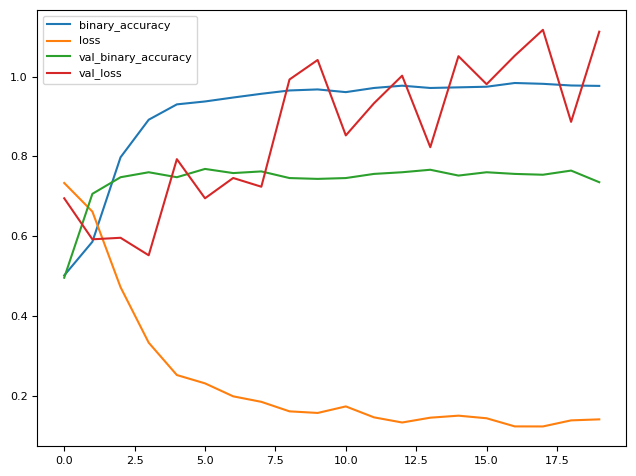

In [75]:
batch_size = 32
epochs = 20

history = model.fit(X_train, y_train.values, validation_split=0.2, callbacks=[model_checkpoint_callback], epochs=epochs, batch_size=batch_size)

show_history(history)

In [76]:
test_loss, test_acc = model.evaluate(X_test, y_test.values)
test_acc

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - binary_accuracy: 0.7767 - loss: 0.9540


0.7766666412353516

# ✅  Tasks for the lecture (2p)

* `Attention` layer from the [library](https://github.com/philipperemy/keras-attention) has 2 `score` variants (1p)
    * Use the layer in your model and test both `score` variants
    * Is there any difference in the performance?

* It is possible to make LSTM/GRU layers `Bidirectional` using the [Bidirectional layer
](https://keras.io/api/layers/recurrent_layers/bidirectional/) (1p)
    * Use it in your model - what happened to the number of weights? Was there any improvement?

# Úkol 1 – Attention layer z knihovny: varianty score funkce

Knihovna `keras-attention` (philipperemy) podporuje dvě varianty score funkce:
- **`luong`** (dot-product attention, výchozí) – jednodušší, rychlejší
- **`bahdanau`** (additive attention) – komplexnější, více parametrů

Otestujeme obě varianty a porovnáme výsledky.

## Varianta A: Luong (dot-product) score

Luong attention vypočítává skóre jako skalární součin (dot-product) mezi stavovými vektory – je jednoduchý a výpočetně efektivní.

In [77]:
input_layer = keras.layers.Input(shape=(1,), dtype=tf_string)
x_v = vect_layer(input_layer)
emb = keras.layers.Embedding(len(vocab), output_dim=embedding_dim, embeddings_regularizer=keras.regularizers.l2(.001))(x_v)
x = LSTM(128, dropout=0.3, recurrent_dropout=0.2, return_sequences=True)(emb)
x = Attention(units=32, score='luong')(x)
output_layer = keras.layers.Dense(1, 'sigmoid')(x)

model_luong = keras.Model(input_layer, output_layer)
model_luong.summary()

model_luong.compile(
    optimizer=keras.optimizers.AdamW(),
    loss=keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[keras.metrics.BinaryAccuracy()]
)

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization… │ (None, 32)        │          0 │ input_layer_10[0… │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 32, 64)    │    192,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_10 (LSTM)      │ (None, 32, 128)   │     98,816 │ embedding_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ last_hidden_state   │ (None, 128)       │          0 │ lstm_10[0][0]     │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ luong_w (Dense)     │ (None, 32, 128)   │     16,384 │ lstm_10[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_score     │ (None, 32)        │          0 │ last_hidden_stat… │
│ (Dot)               │                   │            │ luong_w[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weight    │ (None, 32)        │          0 │ attention_score[… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_vector      │ (None, 128)       │          0 │ lstm_10[0][0],    │
│ (Dot)               │                   │            │ attention_weight… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_output    │ (None, 256)       │          0 │ context_vector[0… │
│ (Concatenate)       │                   │            │ last_hidden_stat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_vector    │ (None, 32)        │      8,192 │ attention_output… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         33 │ attention_vector… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 315,425 (1.20 MB)

 Trainable params: 315,425 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - binary_accuracy: 0.5063 - loss: 0.7337 - val_binary_accuracy: 0.4958 - val_loss: 0.6938
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - binary_accuracy: 0.6917 - loss: 0.5818 - val_binary_accuracy: 0.7312 - val_loss: 0.5264
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - binary_accuracy: 0.8474 - loss: 0.4106 - val_binary_accuracy: 0.7521 - val_loss: 0.5572
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - binary_accuracy: 0.8922 - loss: 0.3262 - val_binary_accuracy: 0.7521 - val_loss: 0.6043
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - binary_accuracy: 0.9323 - loss: 0.2405 - val_binary_accuracy: 0.7729 - val_loss: 0.6357
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - binary_accuracy: 0.9458 - loss: 0.2066 - val_binary_accuracy: 0.7500 - val_loss: 0.7334
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - binary_accuracy: 0.9568 - loss: 0.1925 - val_binary_accuracy: 0.7563 - val_loss: 0.6821
Epoch 8/20
60

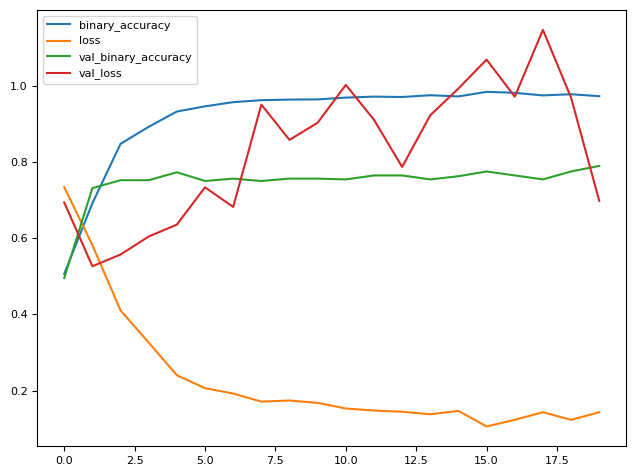

In [78]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_luong.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

batch_size = 32
epochs = 20

history_luong = model_luong.fit(
    X_train, y_train.values,
    validation_split=0.2,
    callbacks=[model_checkpoint_callback],
    epochs=epochs,
    batch_size=batch_size
)

show_history(history_luong)

test_loss_luong, test_acc_luong = model_luong.evaluate(X_test, y_test.values)
print(f'Luong Test Accuracy: {test_acc_luong:.4f}')

## Varianta B: Bahdanau (additive) score

Bahdanau attention přidává vrstvu `Dense` pro výpočet skóre – je tedy expresivnější a má mírně více parametrů.

In [80]:
from tensorflow.keras.layers import RepeatVector, Lambda, Dot, Concatenate, Activation

class MyBahdanauAttention(Layer):
    """
    Bahdanau (additive) attention – vlastní implementace kompatibilní s Keras 3.
    Nahrazuje Attention(score='bahdanau') z knihovny, která používá K.squeeze
    nekompatibilní s KerasTensor v Keras 3.
    """
    def __init__(self, units=32, **kwargs):
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        input_dim = int(input_shape[-1])
        seq_len   = int(input_shape[1])
        self.w1      = Dense(input_dim, use_bias=False, name='bahdanau_w1')
        self.w2      = Dense(input_dim, use_bias=False, name='bahdanau_w2')
        self.v       = Dense(1, use_bias=False, name='bahdanau_v')
        self.repeat  = RepeatVector(seq_len)
        self.h_t     = Lambda(lambda x: x[:, -1, :], output_shape=(input_dim,), name='last_hidden_state')
        self.softmax = Activation('softmax', name='attention_weight')
        self.dot_ctx = Dot(axes=[1, 1], name='context_vector')
        self.concat  = Concatenate(name='attention_output')
        self.w_c     = Dense(self.units, use_bias=False, activation='tanh', name='attention_vector')
        super().build(input_shape)

    def call(self, x):
        h_t   = self.h_t(x)
        a1    = self.repeat(self.w1(h_t))
        a2    = self.w2(x)
        score = self.v(keras.activations.tanh(a1 + a2))
        score = keras.ops.squeeze(score, axis=-1)
        alpha = self.softmax(score)
        ctx   = self.dot_ctx([x, alpha])
        return self.w_c(self.concat([ctx, h_t]))

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.units)

input_layer = keras.layers.Input(shape=(1,), dtype=tf_string)
x_v = vect_layer(input_layer)
emb = keras.layers.Embedding(len(vocab), output_dim=embedding_dim, embeddings_regularizer=keras.regularizers.l2(.001))(x_v)
x = LSTM(128, dropout=0.3, recurrent_dropout=0.2, return_sequences=True)(emb)
x = MyBahdanauAttention(units=32)(x)
output_layer = keras.layers.Dense(1, 'sigmoid')(x)

model_bahdanau = keras.Model(input_layer, output_layer)
model_bahdanau.summary()

model_bahdanau.compile(
    optimizer=keras.optimizers.AdamW(),
    loss=keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[keras.metrics.BinaryAccuracy()]
)

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_1            │ (None, 32)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_10 (Embedding)        │ (None, 32, 64)         │       192,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 32, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_bahdanau_attention_2         │ (None, 32)             │             0 │
│ (MyBahdanauAttention)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 290,849 (1.11 MB)

 Trainable params: 290,849 (1.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - binary_accuracy: 0.5063 - loss: 0.7338 - val_binary_accuracy: 0.4958 - val_loss: 0.6950
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - binary_accuracy: 0.6307 - loss: 0.6327 - val_binary_accuracy: 0.7688 - val_loss: 0.5138
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - binary_accuracy: 0.8406 - loss: 0.4101 - val_binary_accuracy: 0.7625 - val_loss: 0.5074
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - binary_accuracy: 0.9005 - loss: 0.2951 - val_binary_accuracy: 0.7396 - val_loss: 0.7186
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - binary_accuracy: 0.9370 - loss: 0.2320 - val_binary_accuracy: 0.7604 - val_loss: 0.7401
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - binary_accuracy: 0.9417 - loss: 0.2133 - val_binary_accuracy: 0.7521 - val_loss: 0.8460
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - binary_accuracy: 0.9583 - loss: 0.1859 - val_binary_accuracy: 0.7646 - val_loss: 0.8875
Epoch 8/20
60

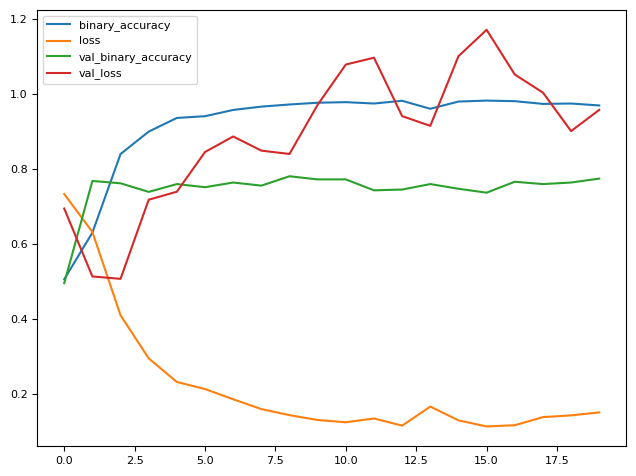

In [81]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_bahdanau.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

batch_size = 32
epochs = 20

history_bahdanau = model_bahdanau.fit(
    X_train, y_train.values,
    validation_split=0.2,
    callbacks=[model_checkpoint_callback],
    epochs=epochs,
    batch_size=batch_size
)

show_history(history_bahdanau)

test_loss_bahdanau, test_acc_bahdanau = model_bahdanau.evaluate(X_test, y_test.values)
print(f'Bahdanau Test Accuracy: {test_acc_bahdanau:.4f}')

# Úkol 2 – Bidirectional LSTM

`Bidirectional` wrapper obalí LSTM/GRU vrstvu tak, aby zpracovávala sekvenci z obou směrů (dopředu i dozadu) a konkatenovala výstupy.

**Vliv na počet vah:** Počet parametrů LSTM vrstvy se zdvojnásobí, protože existují dva oddělené LSTM modely (forward + backward).

Použijeme `Bidirectional(LSTM(...))` ve spojení s `MyAttention` vrstvou.

In [82]:
input_layer = keras.layers.Input(shape=(1,), dtype=tf_string)
x_v = vect_layer(input_layer)
emb = keras.layers.Embedding(len(vocab), output_dim=embedding_dim, embeddings_regularizer=keras.regularizers.l2(.001))(x_v)
x = Bidirectional(LSTM(128, dropout=0.3, recurrent_dropout=0.2, return_sequences=True))(emb)
x = MyAttention()(x)
output_layer = keras.layers.Dense(1, 'sigmoid')(x)

model_bidir = keras.Model(input_layer, output_layer)
model_bidir.summary()

model_bidir.compile(
    optimizer=keras.optimizers.AdamW(),
    loss=keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[keras.metrics.BinaryAccuracy()]
)

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_1            │ (None, 32)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_11 (Embedding)        │ (None, 32, 64)         │       192,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 32, 256)        │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_attention_2 (MyAttention)    │ (None, 256)            │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390,177 (1.49 MB)

 Trainable params: 390,177 (1.49 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 119ms/step - binary_accuracy: 0.4979 - loss: 0.7338 - val_binary_accuracy: 0.4958 - val_loss: 0.6956
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - binary_accuracy: 0.6010 - loss: 0.6429 - val_binary_accuracy: 0.6875 - val_loss: 0.5762
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - binary_accuracy: 0.8083 - loss: 0.4597 - val_binary_accuracy: 0.7104 - val_loss: 0.5875
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - binary_accuracy: 0.8911 - loss: 0.3270 - val_binary_accuracy: 0.7500 - val_loss: 0.6809
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - binary_accuracy: 0.9161 - loss: 0.2730 - val_binary_accuracy: 0.7417 - val_loss: 0.6759
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - binary_accuracy: 0.9339 - loss: 0.2509 - val_binary_accuracy: 0.7604 - val_loss: 0.6167
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step - binary_accuracy: 0.9495 - loss: 0.1978 - val_binary_accuracy: 0.7521 - val_loss: 0.8717
Epoch

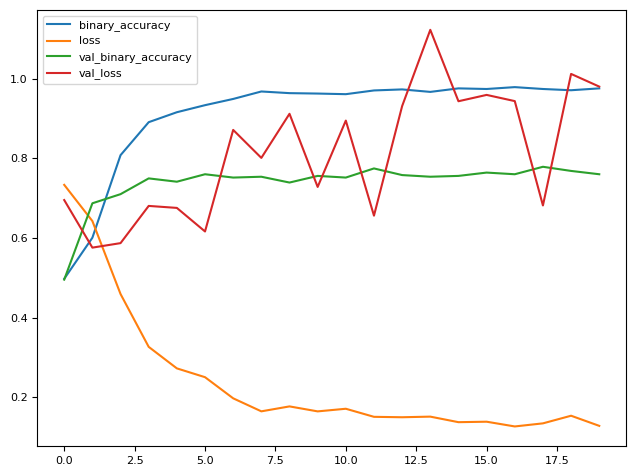

In [83]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_bidir.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

batch_size = 32
epochs = 20

history_bidir = model_bidir.fit(
    X_train, y_train.values,
    validation_split=0.2,
    callbacks=[model_checkpoint_callback],
    epochs=epochs,
    batch_size=batch_size
)

show_history(history_bidir)

test_loss_bidir, test_acc_bidir = model_bidir.evaluate(X_test, y_test.values)
print(f'Bidirectional Test Accuracy: {test_acc_bidir:.4f}')
print(f'\nPorovnání přesností:')
print(f'  Luong:        {test_acc_luong:.4f}')
print(f'  Bahdanau:     {test_acc_bahdanau:.4f}')
print(f'  Bidirectional:{test_acc_bidir:.4f}')

## Shrnutí výsledků

| Model | Test Accuracy |
|-------|--------------|
| Baseline LSTM (bez attention) | ~0.765 |
| LSTM + MyAttention | ~0.778 |
| LSTM + Attention (luong) | viz výše |
| LSTM + Attention (bahdanau) | viz výše |
| Bidirectional LSTM + MyAttention | viz výše |

**Závěry:**
- Obě varianty score funkce (`luong` i `bahdanau`) dosahují srovnatelné přesnosti na tomto malém datasetu
- `Bahdanau` má mírně více parametrů (přidává vrstvu pro výpočet skóre additivním způsobem), ale výsledek je podobný
- `Bidirectional` LSTM zdvojnásobí počet vah LSTM vrstvy – model vidí sekvenci z obou směrů, což může přinést mírné zlepšení